# 05 - Decision Trees & Random Forests

| Transform | Description | Features |
|-----------|-------------|----------|
| T1 (Primera) | Binary enrollment history | `{t}:SUBJ.m` enrolled/not per past term |
| T2 (Segona) | Enriched history + grades | `{t}:SUBJ.m`, `{t}:SUBJ.n`, `{t}:SUBJ.da` attempts |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from educast.config import (
    RANDOM_SEED, TREE_MAX_DEPTH, SUBJECTS_NORMAL, SUBJECTS_ALL,
)
from educast.data.loader import load_university_json, build_acronym_maps
from educast.data.splits import tabular_train_test_split
from educast.features.tabular import identify_feature_types

## 1. Load & Prepare TFG Data

In [2]:
from educast.data.transforms import (
    build_tabular_from_json, primera_transformacio, segona_transformacio,
)

# --- Load university data from standardized JSON ---
print("Loading university data from *.educast.json...")
university_data = load_university_json()
id_to_acr, acr_to_id, acronym_list = build_acronym_maps(university_data)
print(f"Loaded {len(acronym_list)} subject acronyms: {acronym_list[:8]}...")

# --- Build subject name map from JSON ---
subject_name_map = {}
for dept in university_data.get("departments", []):
    for course in dept.get("courses", []):
        acr = course.get("acronym")
        name = course.get("name")
        if acr and name:
            subject_name_map[acr] = name

# --- Build tabular dataset from JSON ---
print("\nBuilding tabular dataset from JSON...")
raw_df = build_tabular_from_json(university_data, id_to_acr)
print(f"Base dataset shape: {raw_df.shape}  ({raw_df['EXPID'].nunique()} students)")

# --- Apply Transform 1 (binary enrollment history) ---
print("\nApplying Transform 1 (binary enrollment history)...")
ds_t1 = primera_transformacio(raw_df, acronym_list)
num_acr = len(acronym_list)
X_t1 = ds_t1.iloc[:, :-num_acr]
y_t1 = ds_t1.iloc[:, -num_acr:]
# Fill missing values
m_cols = X_t1.columns[X_t1.columns.str.endswith(".m")]
n_cols = X_t1.columns[X_t1.columns.str.endswith(".n")]
becat_cols = X_t1.columns[X_t1.columns.str.endswith("becat")]
X_t1[m_cols] = X_t1[m_cols].fillna(False)
X_t1[n_cols] = X_t1[n_cols].fillna(0.0)
X_t1[becat_cols] = X_t1[becat_cols].fillna(False)
for col in ["VIA", "ORDRE", "NACC"]:
    if col in X_t1.columns:
        X_t1[col] = X_t1[col].fillna(0)
print(f"Transform 1: X={X_t1.shape}, y={y_t1.shape}")

# --- Apply Transform 2 (enriched + grades) ---
print("\nApplying Transform 2 (enriched + grades)...")
ds_t2 = segona_transformacio(raw_df, acronym_list)
X_t2 = ds_t2.iloc[:, :-num_acr]
y_t2 = ds_t2.iloc[:, -num_acr:]
for col in ["VIA", "ORDRE", "NACC"]:
    if col in X_t2.columns:
        X_t2[col] = X_t2[col].fillna(0)
print(f"Transform 2: X={X_t2.shape}, y={y_t2.shape}")

Loading university data from *.educast.json...
Loaded 51 subject acronyms: ['AC', 'AE', 'ASI', 'AVD', 'BD', 'BIO', 'CSL', 'CSR']...

Building tabular dataset from JSON...



Building tabular dataset:   0%|          | 0/505 [00:00<?, ?it/s]


Building tabular dataset: 100%|██████████| 505/505 [00:00<00:00, 11059.25it/s]

Base dataset shape: (2477, 1035)  (404 students)

Applying Transform 1 (binary enrollment history)...



Building dataset (Transform 1):   0%|          | 0/404 [00:00<?, ?it/s]

...


Building dataset (Transform 2):  92%|█████████▏| 372/404 [00:08<00:00, 82.11it/s]


Building dataset (Transform 2):  95%|█████████▌| 384/404 [00:08<00:00, 92.66it/s]


Building dataset (Transform 2):  99%|█████████▉| 399/404 [00:08<00:00, 108.75it/s]


Building dataset (Transform 2): 100%|██████████| 404/404 [00:09<00:00, 44.86it/s] 

Transform 2: X=(2073, 159), y=(2073, 51)


## 2. Train Decision Trees (per subject)

Each subject is treated as a **binary classification task**: "will this student enrol in subject X next term?"

**Why depth 4?** The TFG found that depth 5 produces slight overfitting. Depth 4 offers a better bias-variance tradeoff while still capturing multi-level conditional patterns (e.g. "enrolled in SS AND DP AND passed PBN → likely to continue").

Both transforms are used so we can compare whether richer features (T2) improve over binary history (T1).

In [3]:
from educast.models.decision_tree import DecisionTreeManager, SubjectTreePipeline

def train_trees(X, y, acronym_list, max_depth=TREE_MAX_DEPTH, dataset_version="v1"):
    """Train one decision tree per subject."""
    if X is None:
        print("No data available.")
        return None, None, None, None

    cat_feats, num_feats = identify_feature_types(X, dataset_version)
    X_train, X_test, y_train_full, y_test_full = tabular_train_test_split(X, y)

    manager = DecisionTreeManager()
    subjects_to_train = [s for s in acronym_list if s in y.columns]

    for subj in subjects_to_train:
        pipeline = SubjectTreePipeline(
            subject_id=subj,
            y_train=y_train_full[subj].values,
            y_test=y_test_full[subj].values,
            numerical_features=num_feats,
            categorical_features=cat_feats,
            max_depth=max_depth,
        )
        manager.add_model(subj, pipeline)

    manager.fit(subjects_to_train, X_train)
    results = manager.evaluate(X_test)
    return manager, results, X_train, X_test

dt_manager_t1, dt_results_t1, X_train_t1, X_test_t1 = train_trees(
    X_t1, y_t1, acronym_list, dataset_version="v1"
)
if dt_results_t1:
    print(f"\nDecision Tree (T1) — {len(dt_results_t1)} subjects trained")
    for subj, metrics in list(dt_results_t1.items())[:5]:
        r, p, f = metrics
        print(f"  {subj:8s}  Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")

dt_manager_t2, dt_results_t2, X_train_t2, X_test_t2 = train_trees(
    X_t2, y_t2, acronym_list, dataset_version="v2"
)
if dt_results_t2:
    print(f"\nDecision Tree (T2) — {len(dt_results_t2)} subjects trained")
    for subj, metrics in list(dt_results_t2.items())[:5]:
        r, p, f = metrics
        print(f"  {subj:8s}  Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")

  Skipped 7 subjects with no positive test labels: ['AVD', 'BIO', 'CTM', 'OTD', 'Q', 'RM', 'SM']

Decision Tree (T1) — 44 subjects trained
  AC        Recall=0.780  Precision=0.929  F1=0.848
  AE        Recall=0.000  Precision=0.000  F1=0.000
  ASI       Recall=0.840  Precision=0.894  F1=0.866
  BD        Recall=0.606  Precision=0.541  F1=0.571
  CSL       Recall=0.905  Precision=0.731  F1=0.809


  Skipped 7 subjects with no positive test labels: ['AVD', 'BIO', 'CTM', 'OTD', 'Q', 'RM', 'SM']

Decision Tree (T2) — 44 subjects trained
  AC        Recall=0.920  Precision=0.902  F1=0.911
  AE        Recall=0.000  Precision=0.000  F1=0.000
  ASI       Recall=0.920  Precision=0.836  F1=0.876
  BD        Recall=0.667  Precision=0.595  F1=0.629
  CSL       Recall=0.794  Precision=0.962  F1=0.870


## 3. Train Random Forests (per subject, auto n_estimators)

Random Forests are the **best-performing TFG model**. Key advantages over single trees:
- Ensemble averaging reduces overfitting without pruning
- `auto_estimators=True` optimises the number of trees individually per subject (some subjects benefit from more, others from fewer)
- Feature importance averaging across trees is more reliable for identifying key predictors

In [4]:
from educast.models.random_forest import RandomForestManager, SubjectForestPipeline

def train_forests(X, y, acronym_list, dataset_version="v1", auto_estimators=True):
    """Train one random forest per subject with optional auto n_estimators."""
    if X is None:
        print("No data available.")
        return None, None, None, None

    cat_feats, num_feats = identify_feature_types(X, dataset_version)
    X_train, X_test, y_train_full, y_test_full = tabular_train_test_split(X, y)

    manager = RandomForestManager()
    subjects_to_train = [s for s in acronym_list if s in y.columns]

    for subj in subjects_to_train:
        pipeline = SubjectForestPipeline(
            subject_id=subj,
            y_train=y_train_full[subj].values,
            y_test=y_test_full[subj].values,
            numerical_features=num_feats,
            categorical_features=cat_feats,
            auto_estimators=auto_estimators,
        )
        manager.add_model(subj, pipeline)

    manager.fit(subjects_to_train, X_train)
    results = manager.evaluate(X_test)
    return manager, results, X_train, X_test

rf_manager_t1, rf_results_t1, _, _ = train_forests(
    X_t1, y_t1, acronym_list, dataset_version="v1"
)
if rf_results_t1:
    print(f"\nRandom Forest (T1) — {len(rf_results_t1)} subjects trained")
    for subj, metrics in list(rf_results_t1.items())[:5]:
        r, p, f = metrics
        print(f"  {subj:8s}  Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")

rf_manager_t2, rf_results_t2, _, _ = train_forests(
    X_t2, y_t2, acronym_list, dataset_version="v2"
)
if rf_results_t2:
    print(f"\nRandom Forest (T2) — {len(rf_results_t2)} subjects trained")
    for subj, metrics in list(rf_results_t2.items())[:5]:
        r, p, f = metrics
        print(f"  {subj:8s}  Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM

...

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  Skipped 7 subjects with no positive test labels: ['AVD', 'BIO', 'CTM', 'OTD', 'Q', 'RM', 'SM']

Random Forest (T2) — 44 subjects trained
  AC        Recall=0.760  Precision=0.927  F1=0.835
  AE        Recall=0.000  Precision=0.000  F1=0.000
  ASI       Recall=0.900  Precision=0.882  F1=0.891
  BD        Recall=0.273  Precision=0.900  F1=0.419
  CSL       Recall=0.794  Precision=0.909  F1=0.847


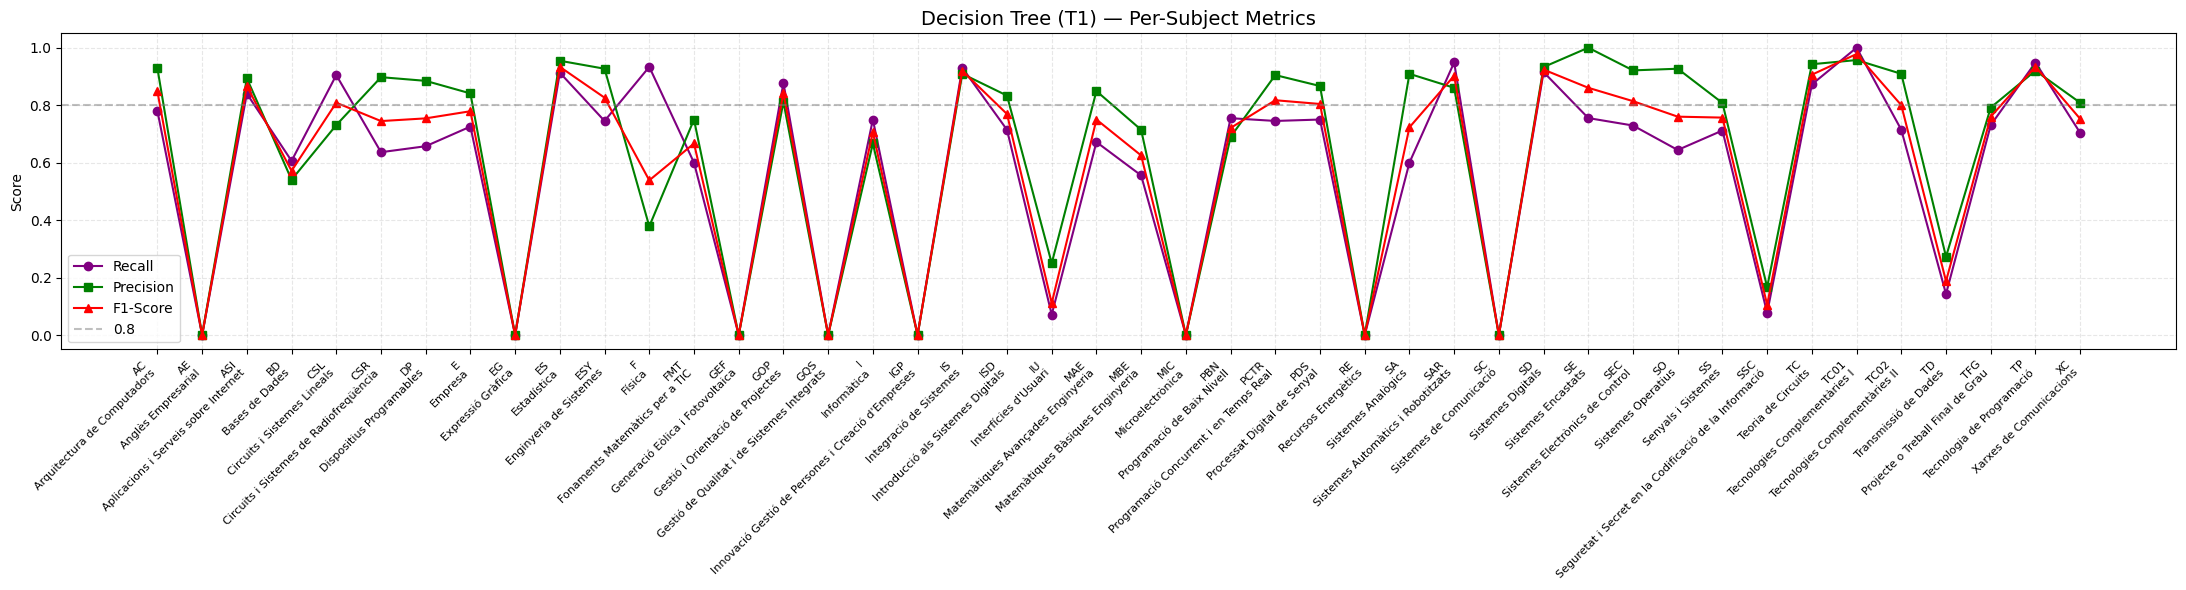

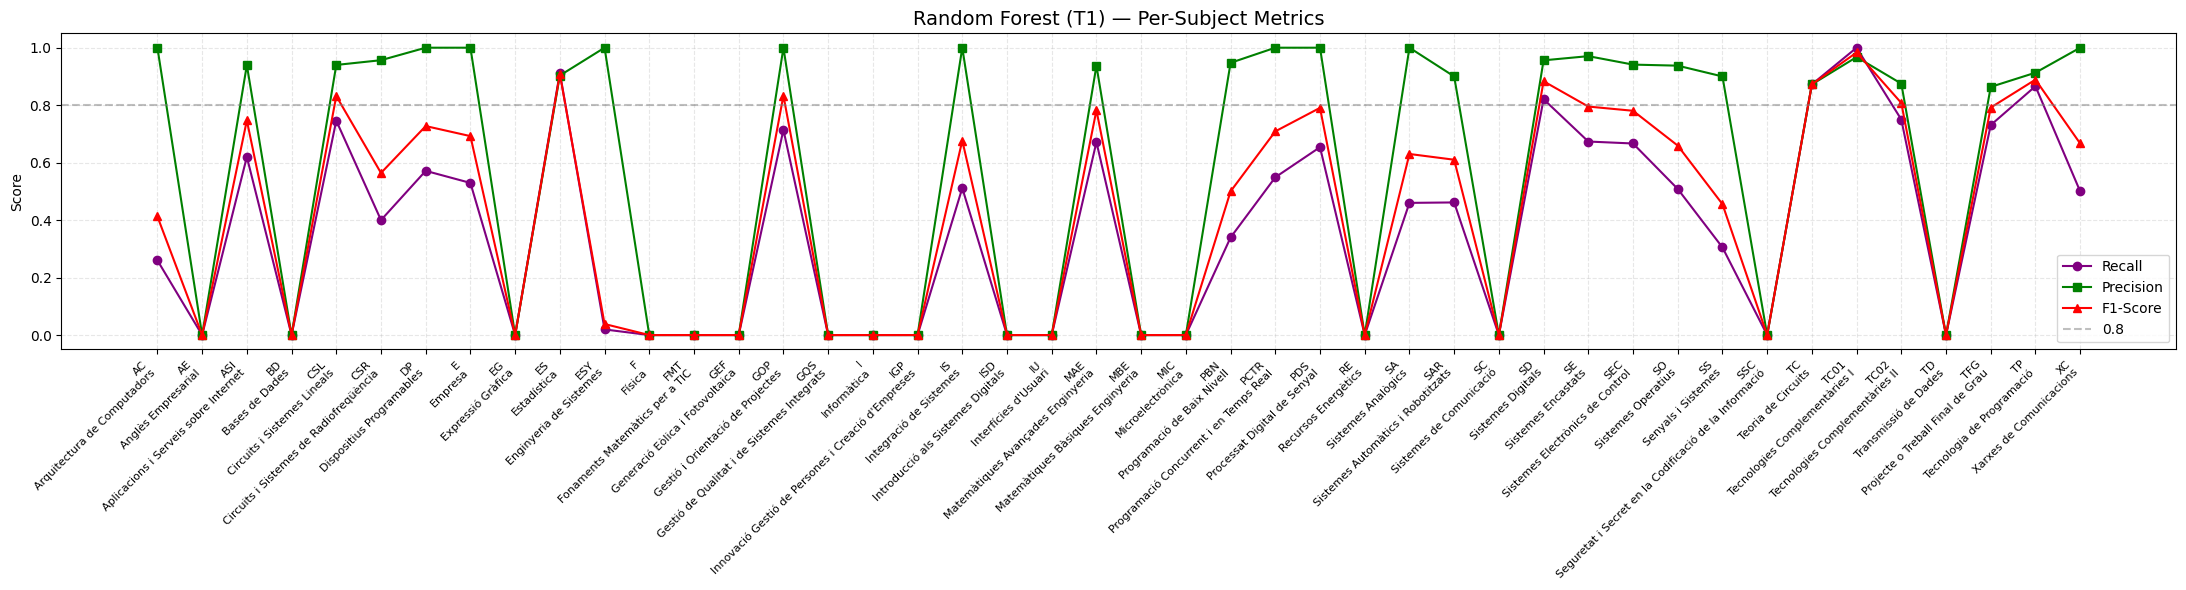

In [5]:
from educast.evaluation.metrics import per_subject_classification_metrics
from educast.visualization.plots import plot_classification_metrics

if X_t1 is not None and dt_results_t1:
    df_dt = per_subject_classification_metrics(dt_results_t1)
    fig = plot_classification_metrics(
        df_dt,
        title="Decision Tree (T1) — Per-Subject Metrics",
        subject_name_map=subject_name_map,
    )
    plt.show()

    df_rf = per_subject_classification_metrics(rf_results_t1)
    fig = plot_classification_metrics(
        df_rf,
        title="Random Forest (T1) — Per-Subject Metrics",
        subject_name_map=subject_name_map,
    )
    plt.show()

## 5. Feature Importance

The feature importance heatmap shows which **past enrollments** (and grades/attempts in T2) most influence each subject's prediction.

In [6]:
from educast.visualization.feature_importance import plot_feature_importance_heatmap

if X_t1 is not None and rf_manager_t1:
    fig = plot_feature_importance_heatmap(
        rf_manager_t1, title="Random Forest Feature Importance Heatmap"
    )
    plt.show()

## 6. Trees rendering

Decision tree graphs for key subjects at depth 4. These show the actual decision rules learned.

**How to read the trees:**
- Each internal node shows a feature split (e.g. `DP.m <= 0.5` = not enrolled in DP)
- **Gini** is the impurity measure, lower = purer node (more confident prediction)
- **value = [0, 1]** = number of training samples in each class (0 = won't enrol, 1 = will enrol)
- Leaf nodes give the final prediction

**Subjects visualised: SS, DP, PBN, XC.** As seen in the TFG as the four most feature-important subjects, their past enrollment is the strongest predictor for many others.

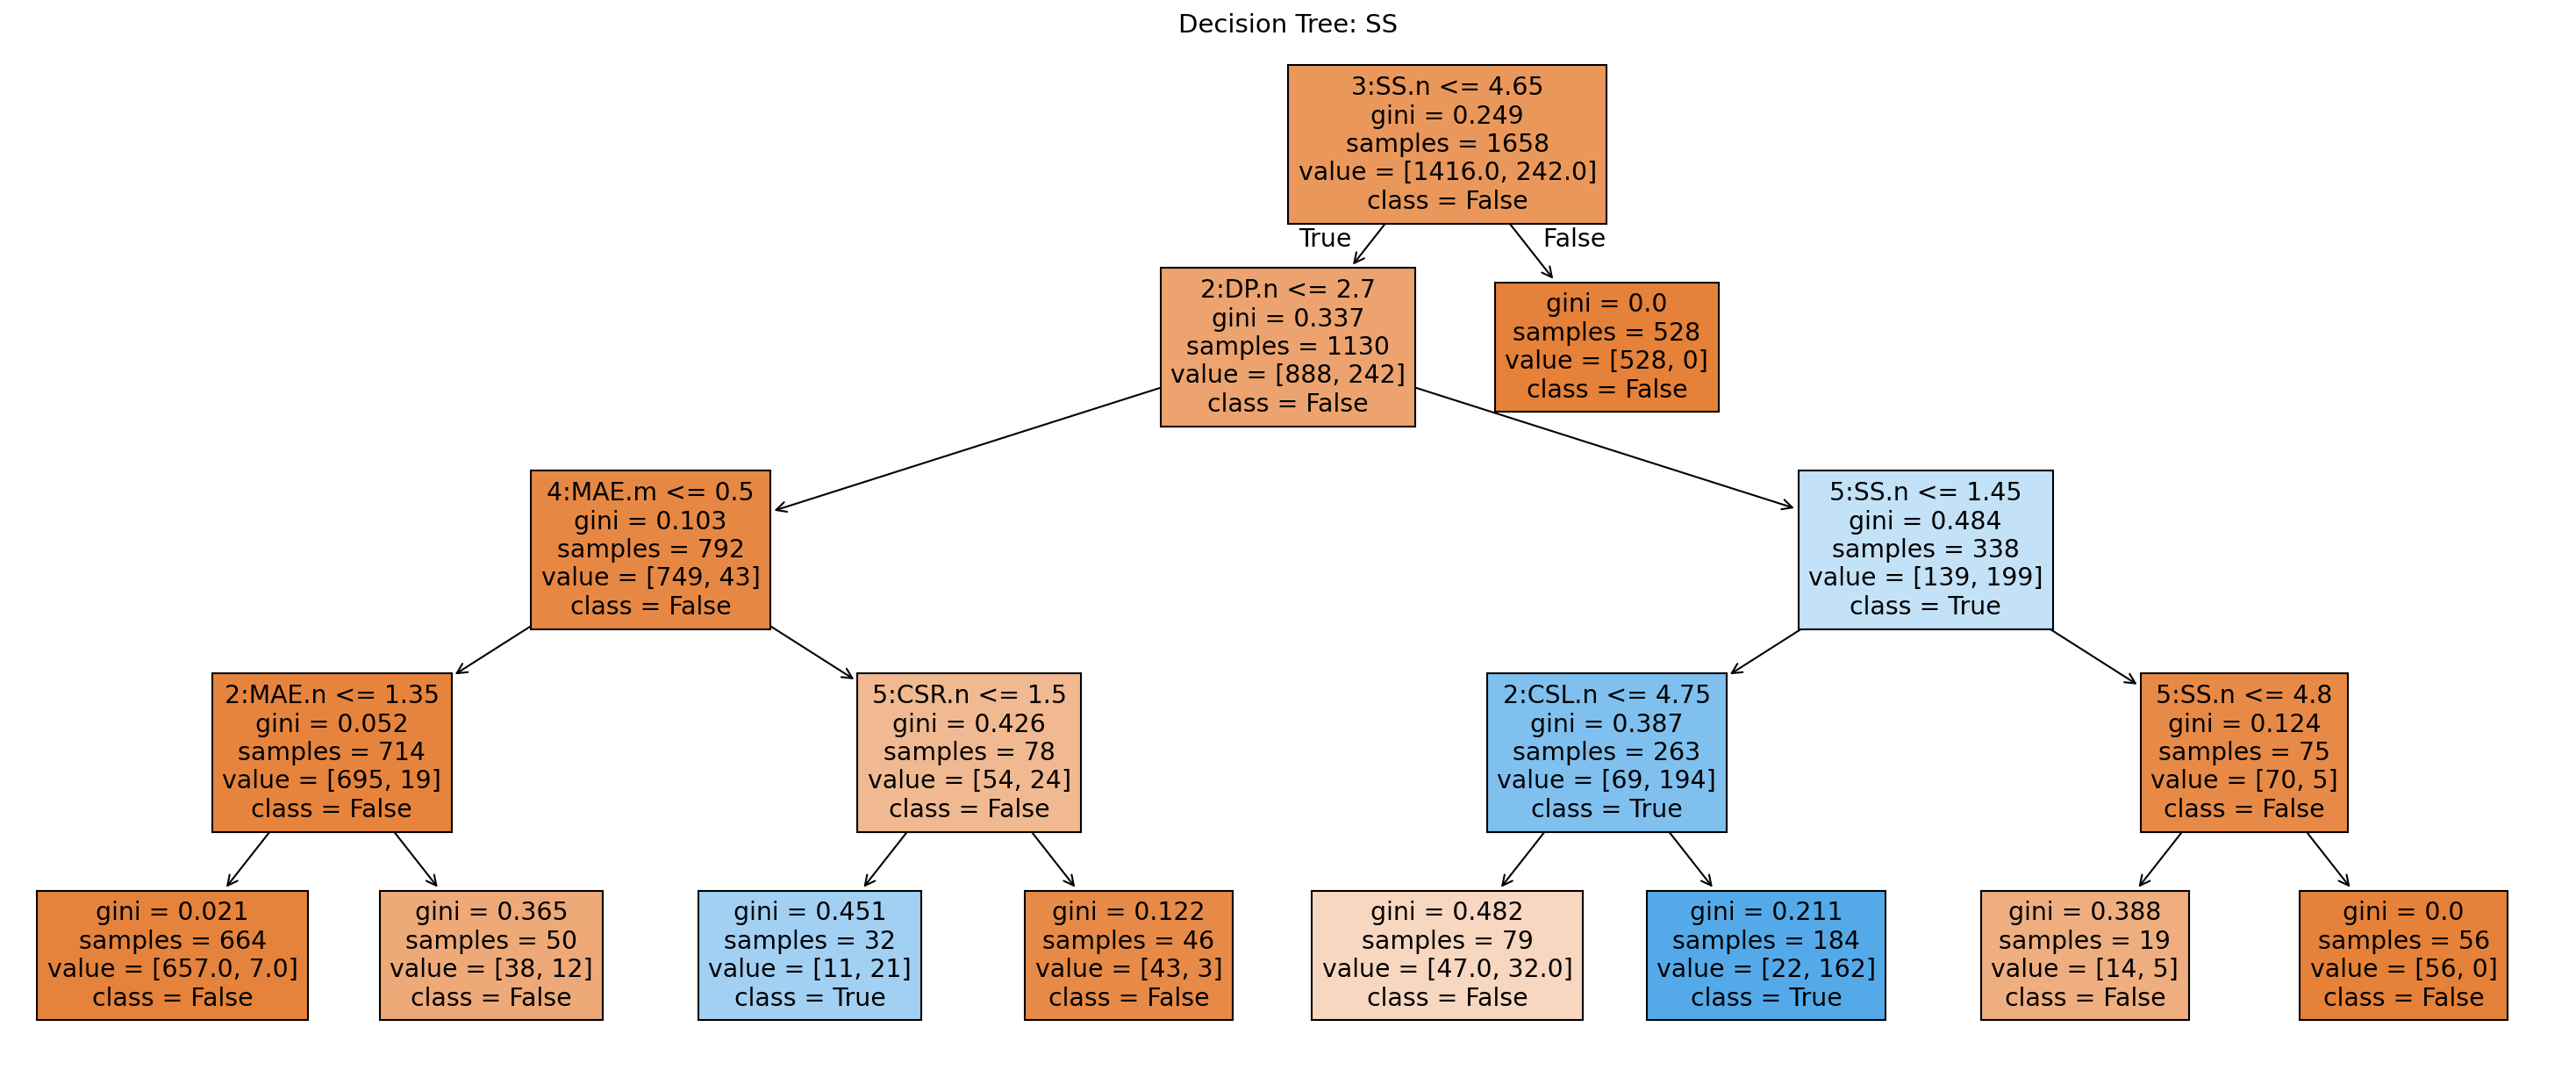

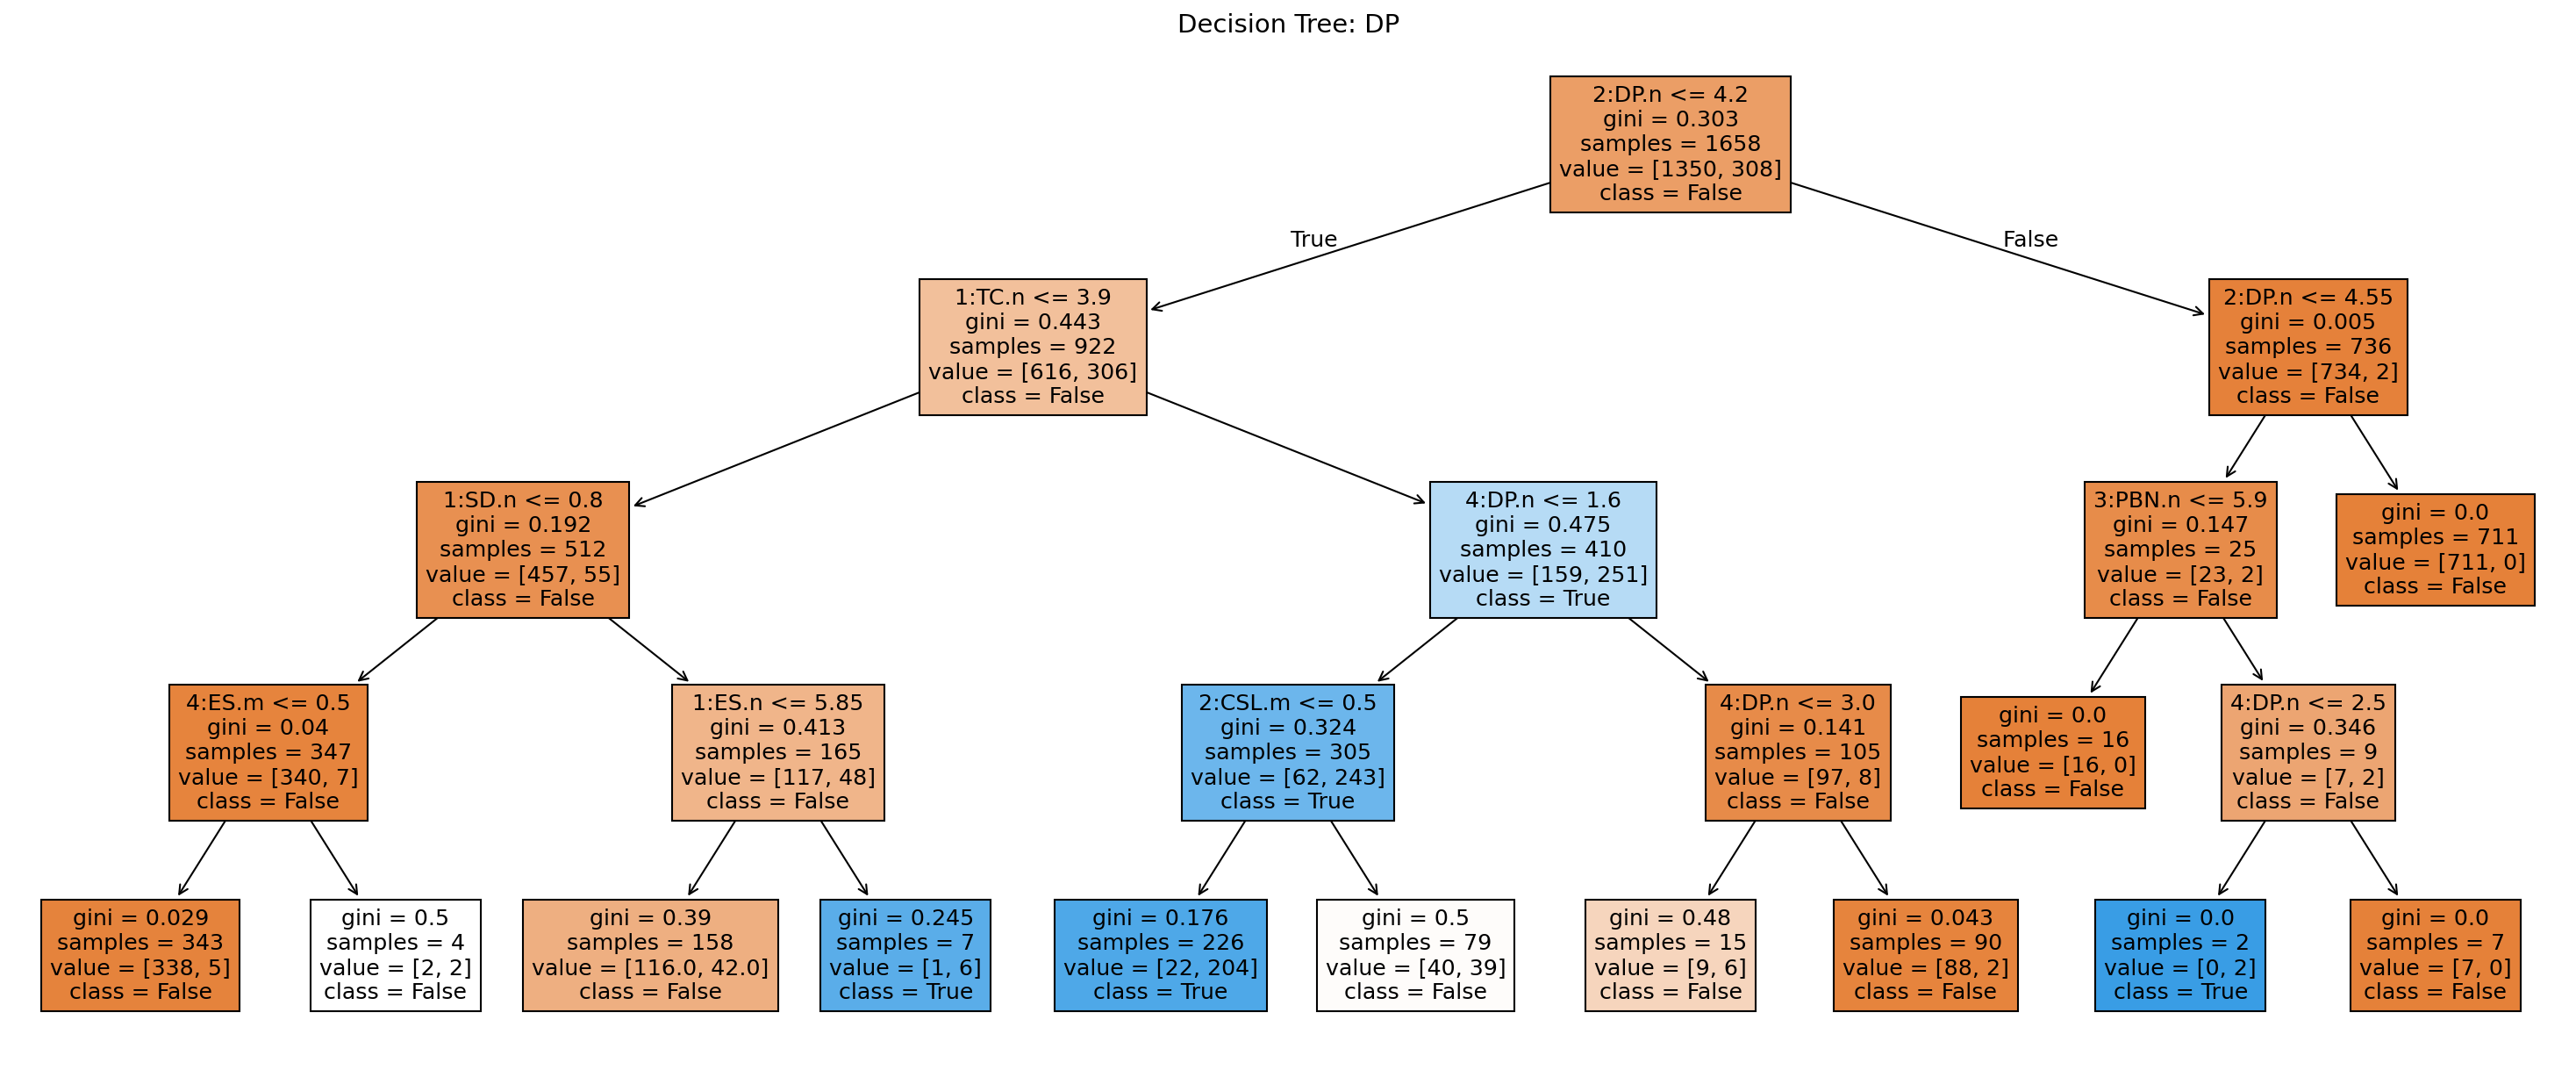

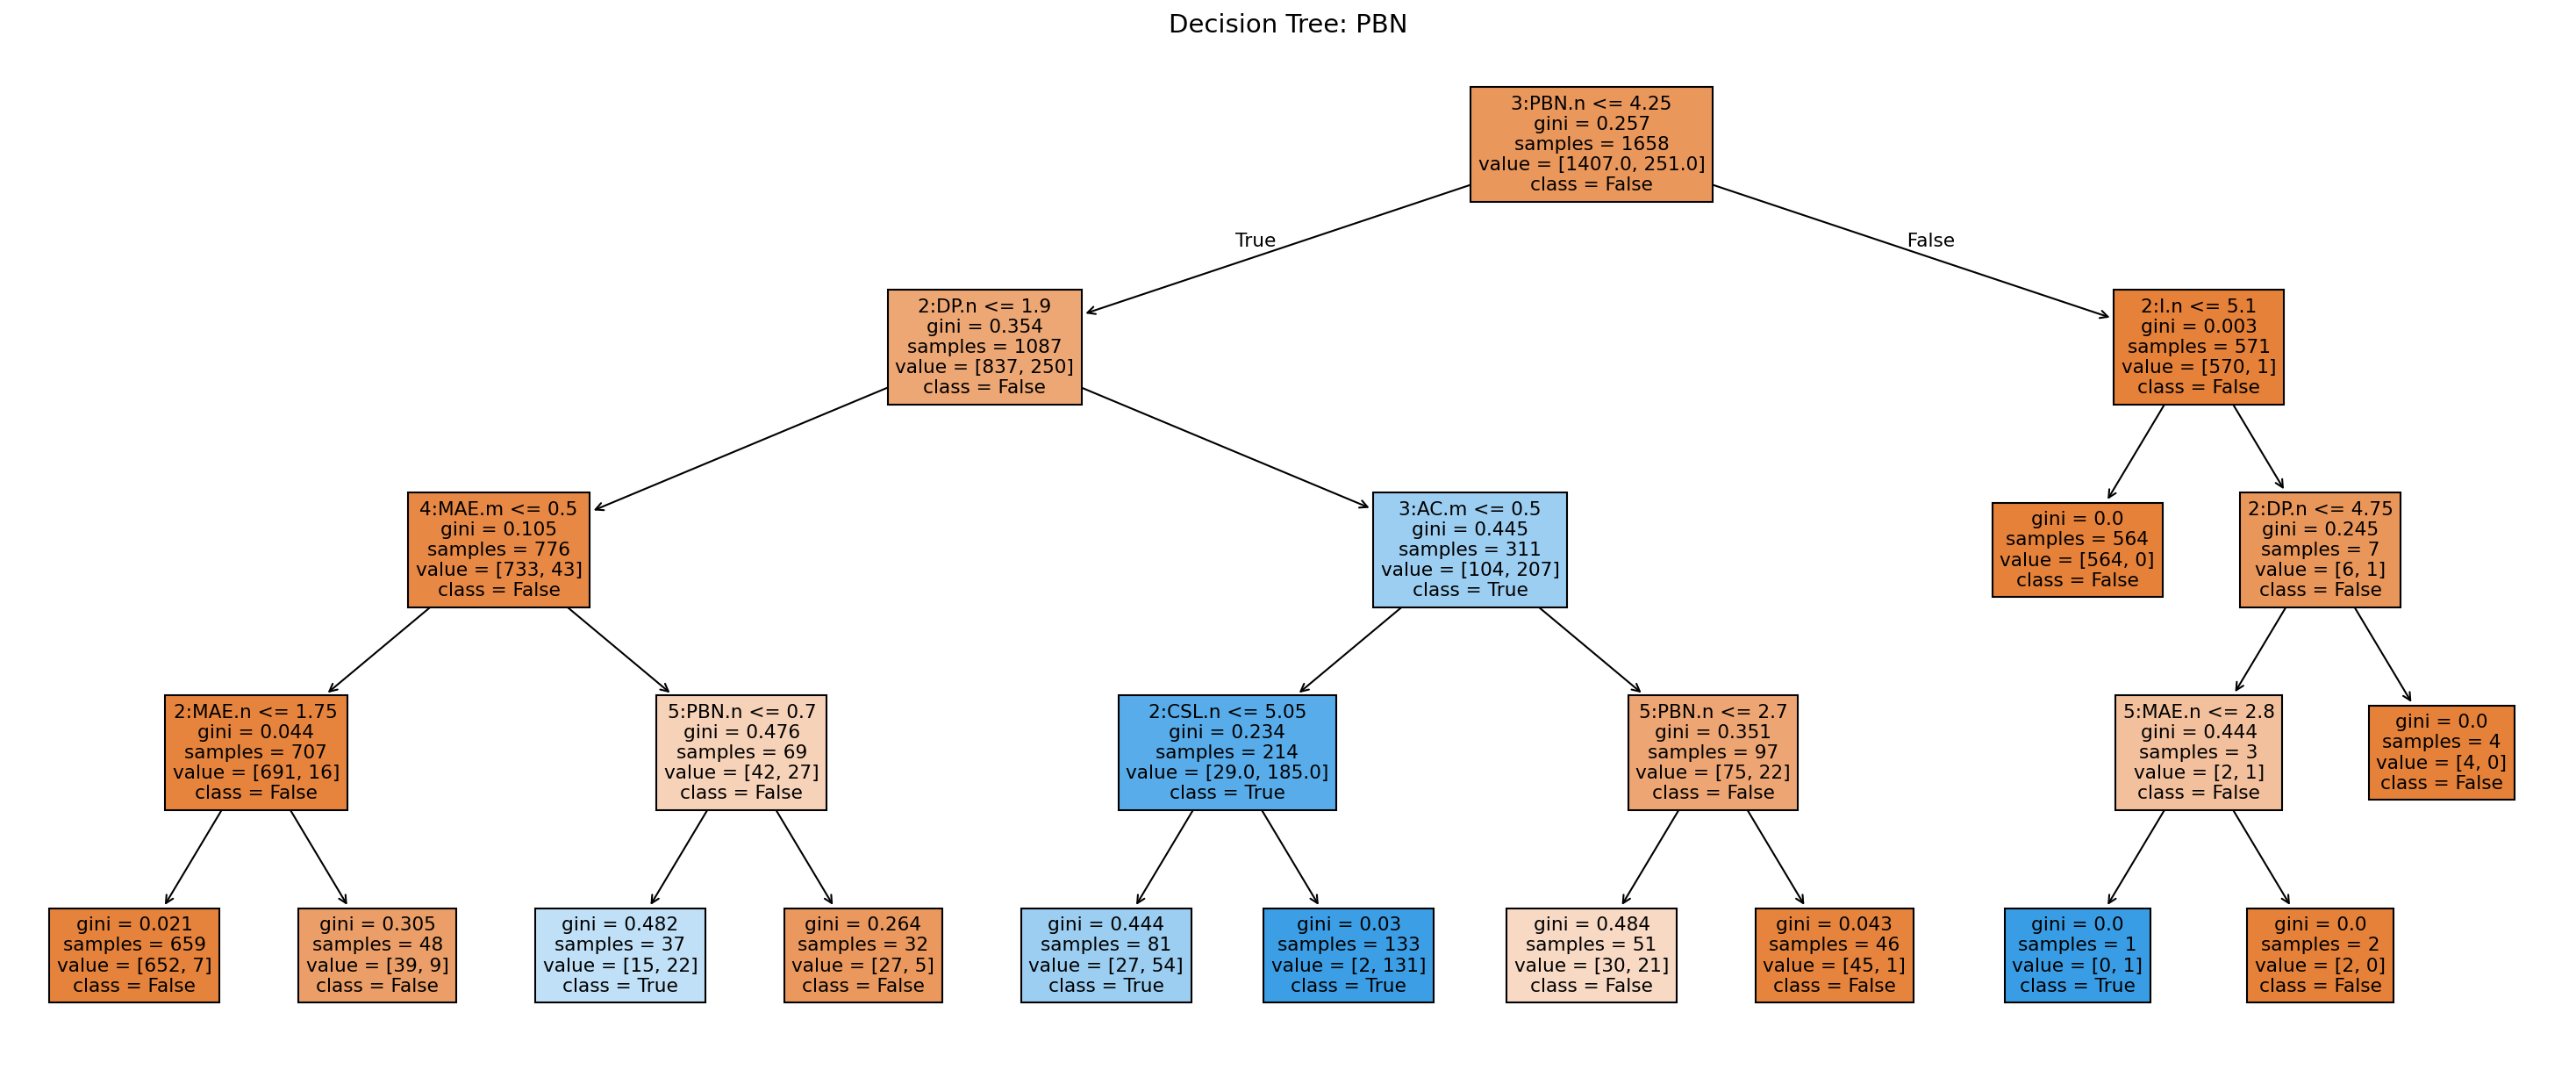

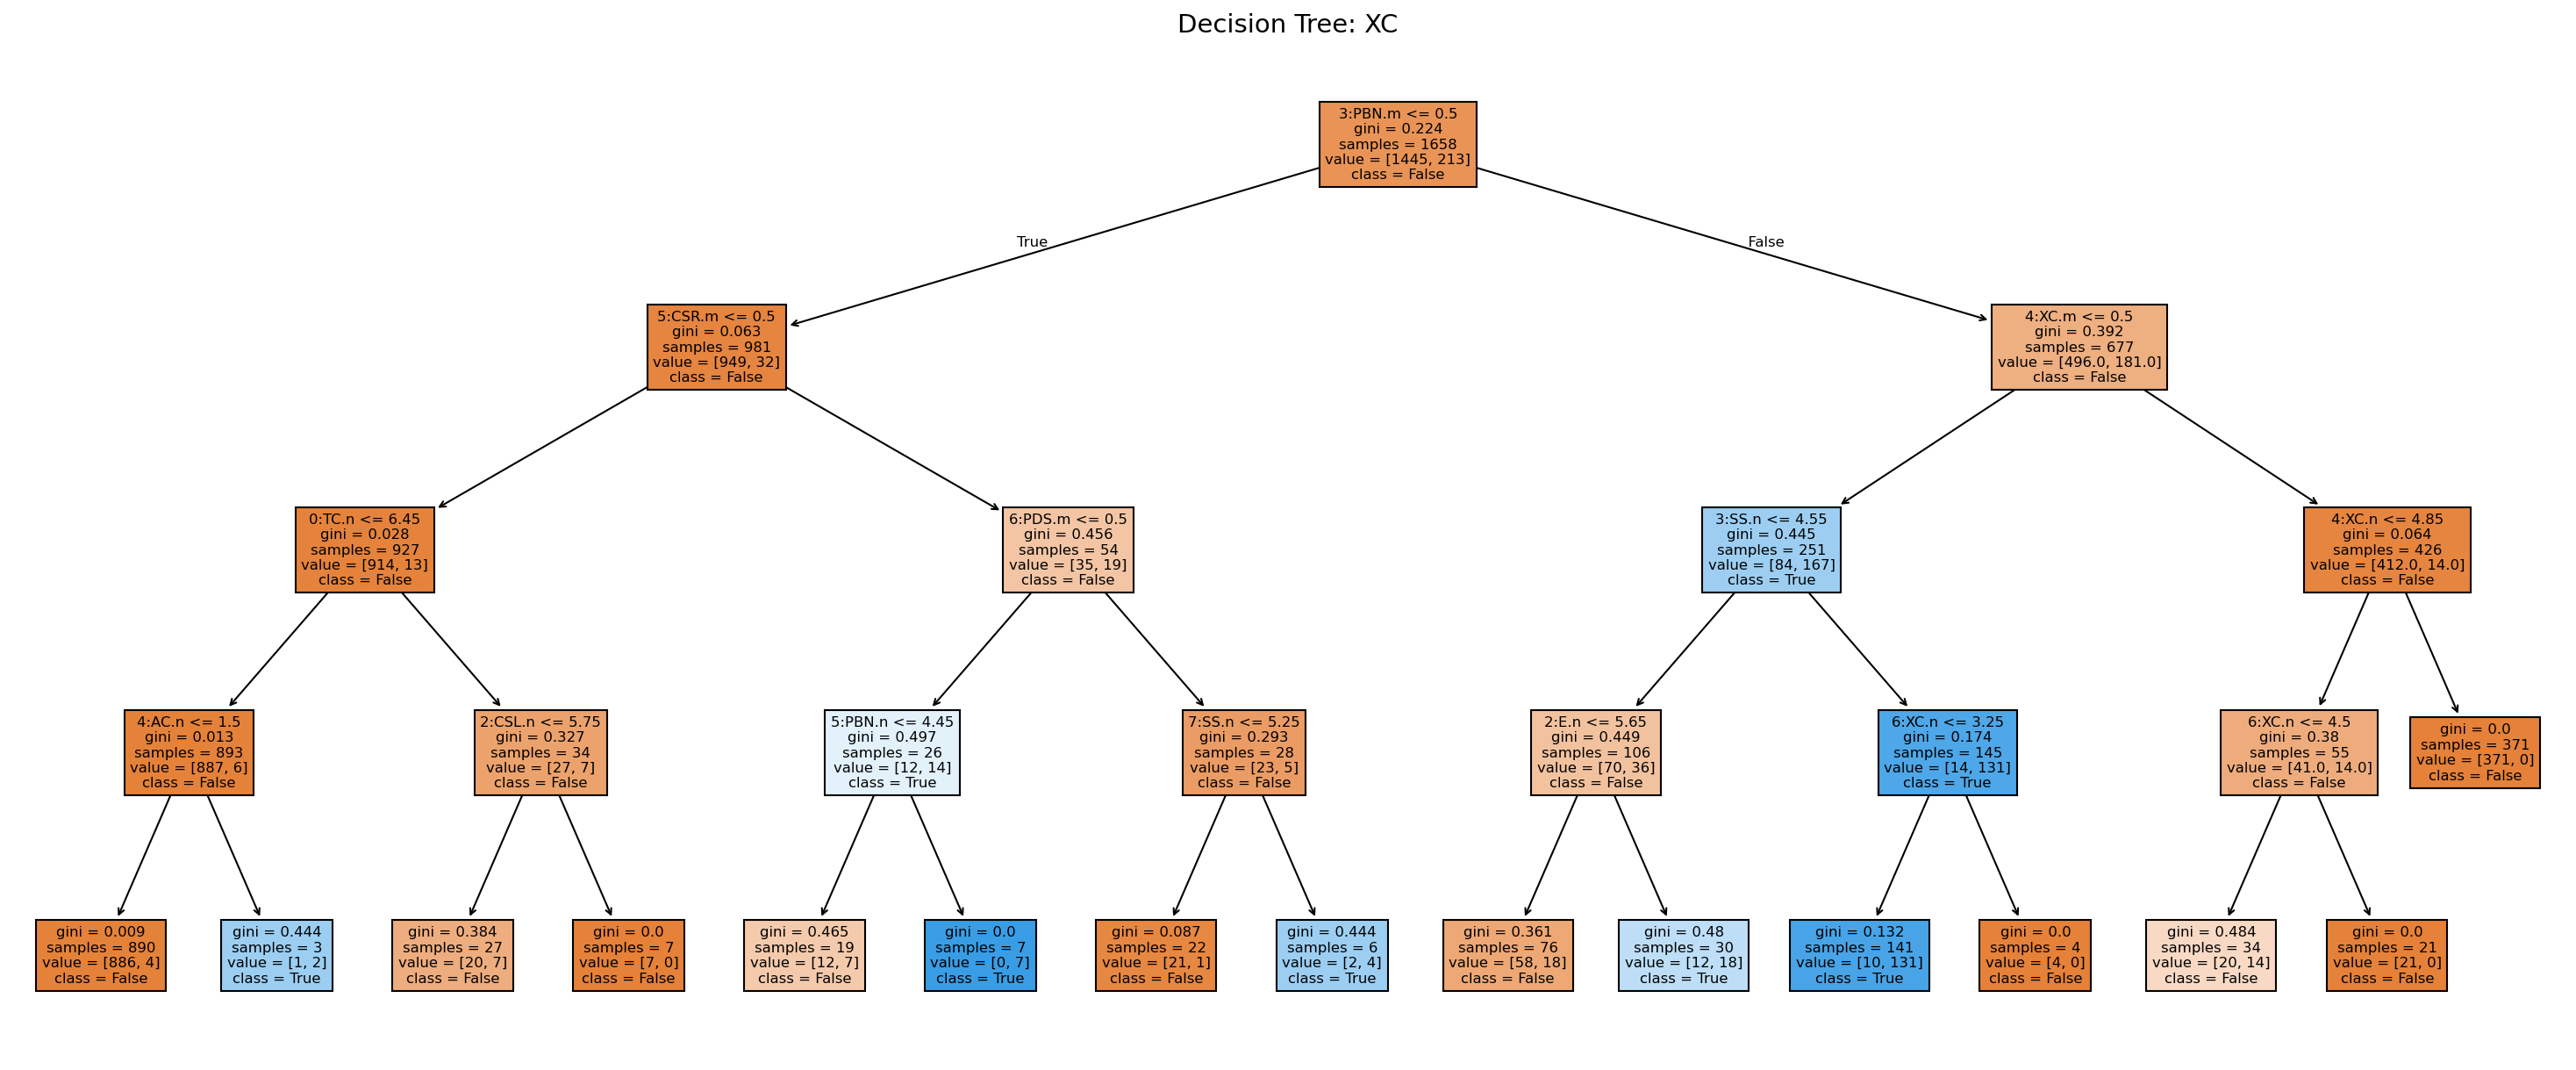

In [ ]:
from educast.visualization.trees import plot_decision_tree

if X_t1 is not None and dt_manager_t1:
    key_subjects = ["SS", "DP", "PBN", "XC"]
    for subj in key_subjects:
        if subj in dt_manager_t1.models:
            fig = plot_decision_tree(dt_manager_t1[subj], transform_name="t1", show=True)

In [8]:
from educast.evaluation.metrics import per_subject_classification_metrics
from educast.evaluation.export import export_results

results_summary = []
for label, results in [
    ("decision_tree_t1", dt_results_t1),
    ("decision_tree_t2", dt_results_t2),
    ("random_forest_t1", rf_results_t1),
    ("random_forest_t2", rf_results_t2),
]:
    if results is None:
        continue
    df_metrics = per_subject_classification_metrics(results)
    avg_f1 = df_metrics["F1"].mean()
    avg_recall = df_metrics["Recall"].mean()
    avg_precision = df_metrics["Precision"].mean()
    results_summary.append({
        "Model": label, "Avg F1": avg_f1,
        "Avg Recall": avg_recall, "Avg Precision": avg_precision,
    })
    model_name, transform = label.rsplit("_", 1)
    export_results(
        label, {"avg_F1": avg_f1, "avg_Recall": avg_recall, "avg_Precision": avg_precision},
        df_metrics,
        {"model": model_name, "transform": transform, "max_depth": TREE_MAX_DEPTH, "seed": RANDOM_SEED},
    )

if results_summary:
    df_summary = pd.DataFrame(results_summary).set_index("Model")
    print("\n=== Summary Table ===")
    print(df_summary.round(3).to_string())
    print("\nBest model by F1:", df_summary["Avg F1"].idxmax())
else:
    print("No results to export. Run training cells first.")


=== Summary Table ===
                  Avg F1  Avg Recall  Avg Precision
Model                                              
decision_tree_t1   0.604       0.583          0.644
decision_tree_t2   0.653       0.650          0.670
random_forest_t1   0.433       0.366          0.585
random_forest_t2   0.549       0.509          0.653

Best model by F1: decision_tree_t2
